# Double Pendulum Simulation

This notebook sets up a double pendulum solver and a reusable plotting pipeline.

The current version includes a small sweep over different initial angles so we can generate a series of graphs and refine the exact graph content afterward.

We start by importing the numerical and plotting tools used throughout the notebook.

In [7]:
%matplotlib inline

import numpy as np
from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.integrate import solve_ivp

plt.style.use('seaborn-v0_8-darkgrid')

Next we define the equations of motion, the position conversion, and a small energy helper.

In [8]:
DEFAULT_PARAMS = {
    'm1': 1.0,
    'm2': 1.0,
    'l1': 1.0,
    'l2': 1.0,
    'g': 9.81,
}


def double_pendulum_derivatives(t, state, m1=1.0, m2=1.0, l1=1.0, l2=1.0, g=9.81):
    theta1, omega1, theta2, omega2 = state
    delta = theta2 - theta1

    denom = 2 * m1 + m2 - m2 * np.cos(2 * delta)

    dtheta1 = omega1
    dtheta2 = omega2

    domega1 = (
        -g * (2 * m1 + m2) * np.sin(theta1)
        - m2 * g * np.sin(theta1 - 2 * theta2)
        - 2 * np.sin(delta) * m2 * (omega2**2 * l2 + omega1**2 * l1 * np.cos(delta))
    ) / (l1 * denom)

    domega2 = (
        2 * np.sin(delta) * (
            omega1**2 * l1 * (m1 + m2)
            + g * (m1 + m2) * np.cos(theta1)
            + omega2**2 * l2 * m2 * np.cos(delta)
        )
    ) / (l2 * denom)

    return [dtheta1, domega1, dtheta2, domega2]


def pendulum_positions(theta1, theta2, l1=1.0, l2=1.0):
    x1 = l1 * np.sin(theta1)
    y1 = -l1 * np.cos(theta1)
    x2 = x1 + l2 * np.sin(theta2)
    y2 = y1 - l2 * np.cos(theta2)
    return x1, y1, x2, y2


def total_energy(theta1, omega1, theta2, omega2, m1=1.0, m2=1.0, l1=1.0, l2=1.0, g=9.81):
    x1, y1, x2, y2 = pendulum_positions(theta1, theta2, l1=l1, l2=l2)

    v1_sq = (l1 * omega1) ** 2
    v2_sq = v1_sq + (l2 * omega2) ** 2 + 2 * l1 * l2 * omega1 * omega2 * np.cos(theta1 - theta2)

    kinetic = 0.5 * m1 * v1_sq + 0.5 * m2 * v2_sq
    potential = m1 * g * y1 + m2 * g * y2
    return kinetic + potential

This cell runs the simulation for one initial state and returns the full time series, bob positions, and energy.

In [10]:
def simulate_double_pendulum(initial_state, t_max=20.0, n_points=4000, params=None):
    if params is None:
        params = DEFAULT_PARAMS

    t_eval = np.linspace(0.0, t_max, n_points)

    solution = solve_ivp(
        double_pendulum_derivatives,
        (0.0, t_max),
        initial_state,
        t_eval=t_eval,
        args=(params['m1'], params['m2'], params['l1'], params['l2'], params['g']),
        rtol=1e-8,
        atol=1e-8,
    )

    theta1, omega1, theta2, omega2 = solution.y
    x1, y1, x2, y2 = pendulum_positions(theta1, theta2, l1=params['l1'], l2=params['l2'])
    energy = total_energy(
        theta1, omega1, theta2, omega2,
        m1=params['m1'], m2=params['m2'], l1=params['l1'], l2=params['l2'], g=params['g'],
    )

    return {
        't': solution.t,
        'theta1': theta1,
        'omega1': omega1,
        'theta2': theta2,
        'omega2': omega2,
        'x1': x1,
        'y1': y1,
        'x2': x2,
        'y2': y2,
        'energy': energy,
        'initial_state': np.array(initial_state, dtype=float),
        'params': params.copy(),
    }

The next cell defines the graph templates. Right now it produces a standard set of figures for each starting position, and it is easy to swap or add graphs once you tell me what the final series should contain.

In [3]:
def plot_double_pendulum_summary(result, label):
    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    fig.suptitle(label, fontsize=16)

    axes[0, 0].plot(result['t'], result['theta1'], label=r'$\theta_1$')
    axes[0, 0].plot(result['t'], result['theta2'], label=r'$\theta_2$')
    axes[0, 0].set_title('Angles over time')
    axes[0, 0].set_xlabel('Time (s)')
    axes[0, 0].set_ylabel('Angle (rad)')
    axes[0, 0].legend()

    axes[0, 1].plot(result['theta1'], result['omega1'], label=r'$\theta_1$ vs $\omega_1$')
    axes[0, 1].plot(result['theta2'], result['omega2'], label=r'$\theta_2$ vs $\omega_2$')
    axes[0, 1].set_title('Phase portrait')
    axes[0, 1].set_xlabel('Angle (rad)')
    axes[0, 1].set_ylabel('Angular velocity (rad/s)')
    axes[0, 1].legend()

    axes[1, 0].plot(result['x1'], result['y1'], label='Mass 1 path')
    axes[1, 0].plot(result['x2'], result['y2'], label='Mass 2 path')
    axes[1, 0].set_title('Path in Cartesian space')
    axes[1, 0].set_xlabel('x')
    axes[1, 0].set_ylabel('y')
    axes[1, 0].axis('equal')
    axes[1, 0].legend()

    axes[1, 1].plot(result['t'], result['energy'])
    axes[1, 1].set_title('Total energy')
    axes[1, 1].set_xlabel('Time (s)')
    axes[1, 1].set_ylabel('Energy')

    fig.tight_layout()
    plt.show()


def animate_double_pendulum(result, interval=20):
    fig, ax = plt.subplots(figsize=(6, 6))
    params = result['params']
    l1 = params['l1']
    l2 = params['l2']

    limit = l1 + l2 + 0.2
    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    ax.set_aspect('equal')
    ax.set_title('Double pendulum animation')

    line, = ax.plot([], [], 'o-', lw=2)
    trace, = ax.plot([], [], '-', alpha=0.5)

    def update(frame):
        x = [0, result['x1'][frame], result['x2'][frame]]
        y = [0, result['y1'][frame], result['y2'][frame]]
        line.set_data(x, y)
        trace.set_data(result['x2'][:frame + 1], result['y2'][:frame + 1])
        return line, trace

    return FuncAnimation(fig, update, frames=len(result['t']), interval=interval, blit=True)

Now we define a small sweep of different initial angles. You can replace or expand this list once you decide exactly which positions should be compared.

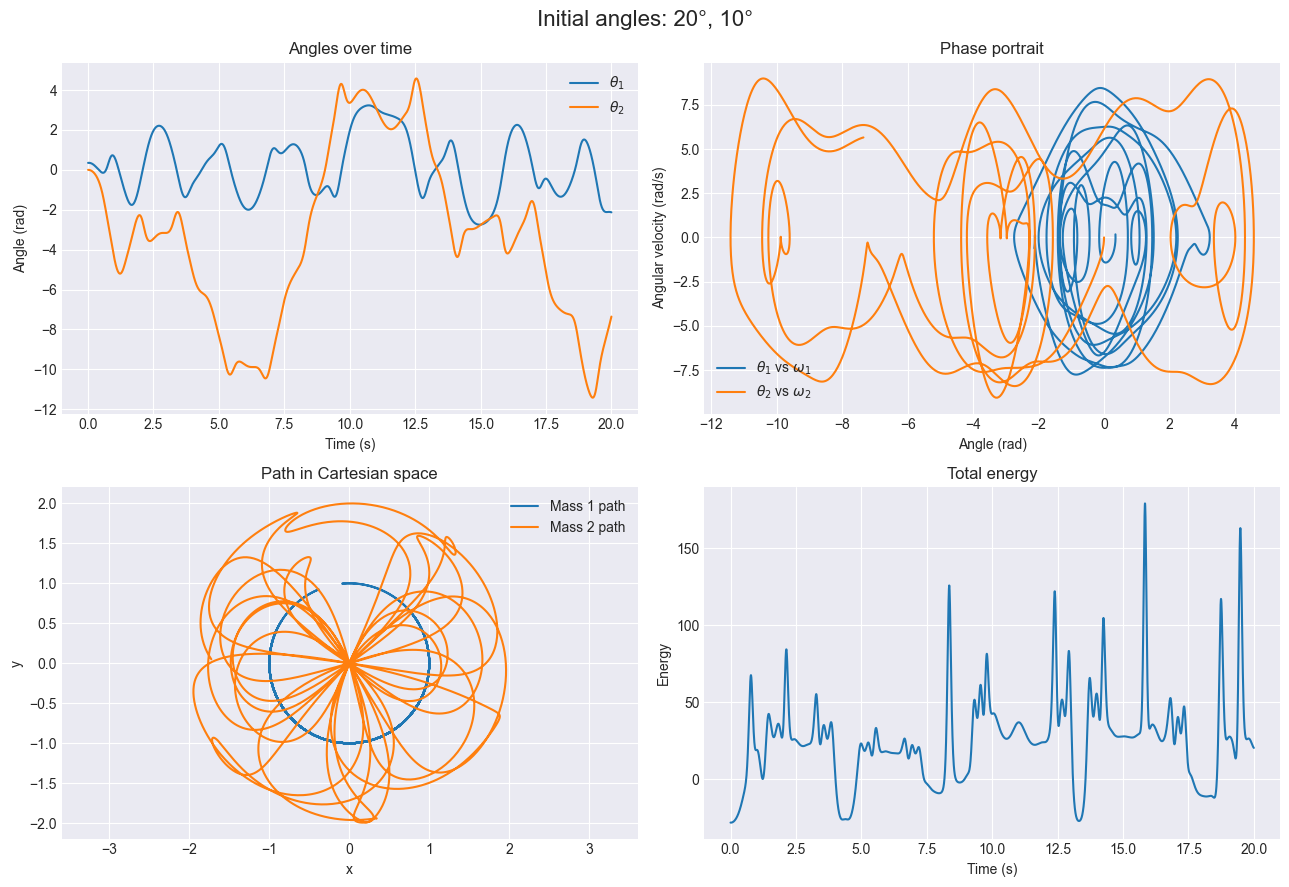

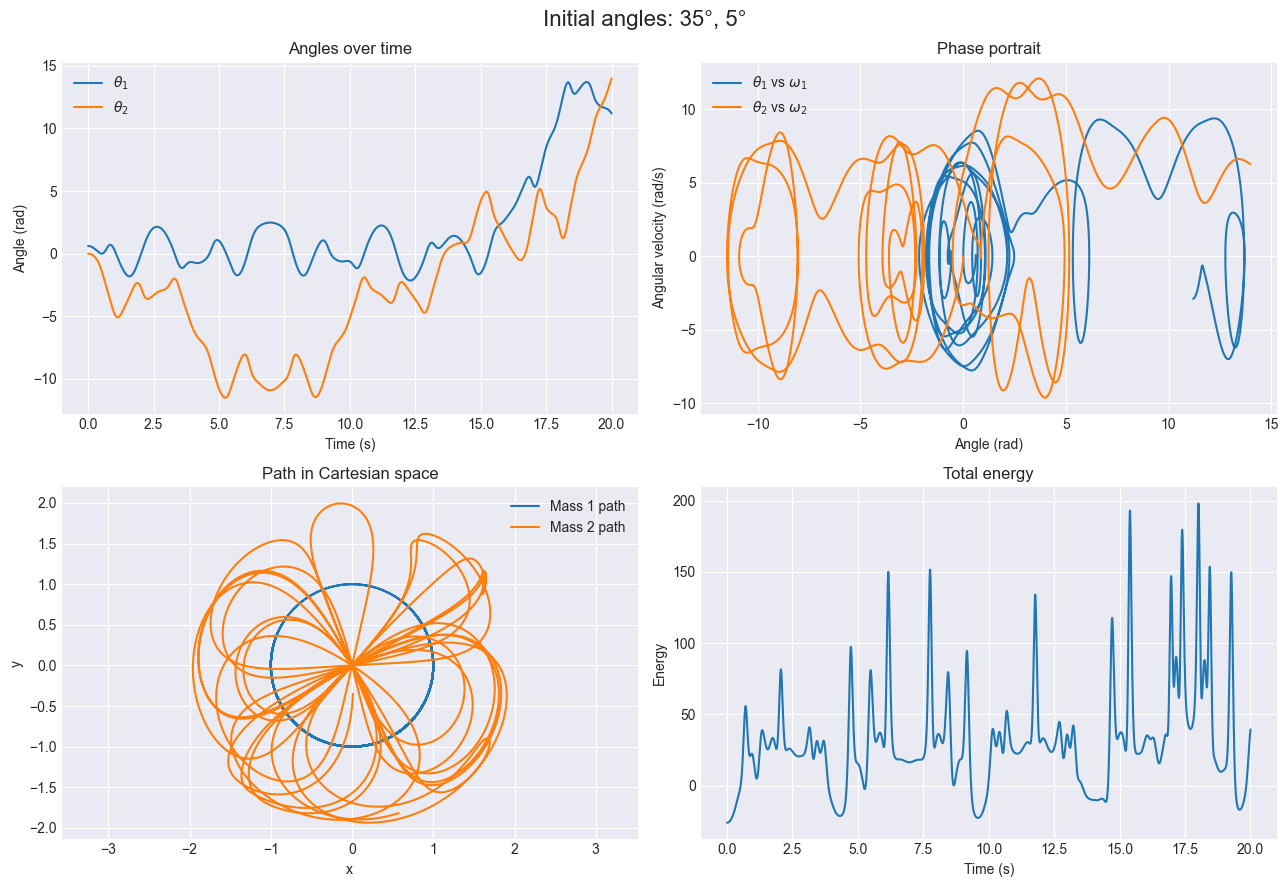

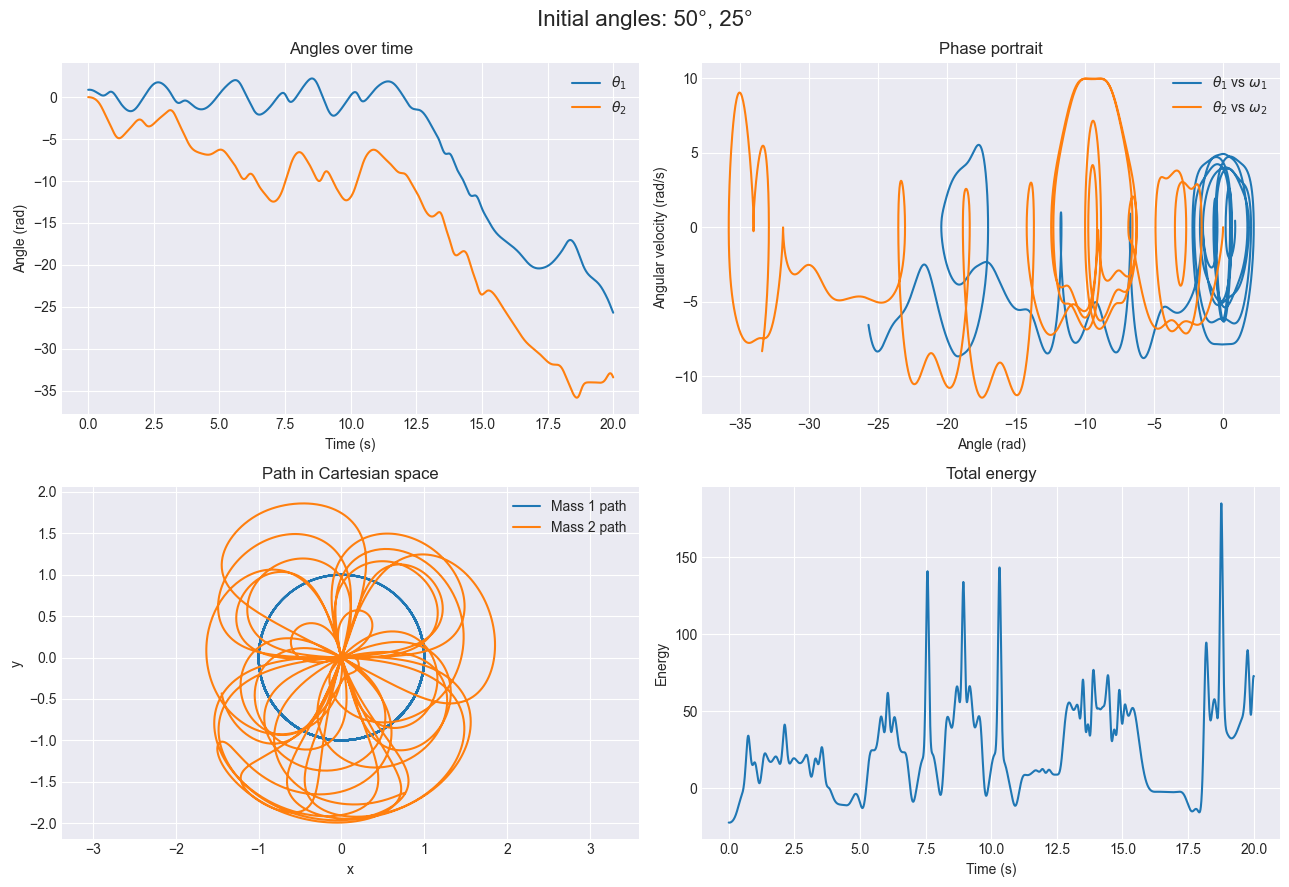

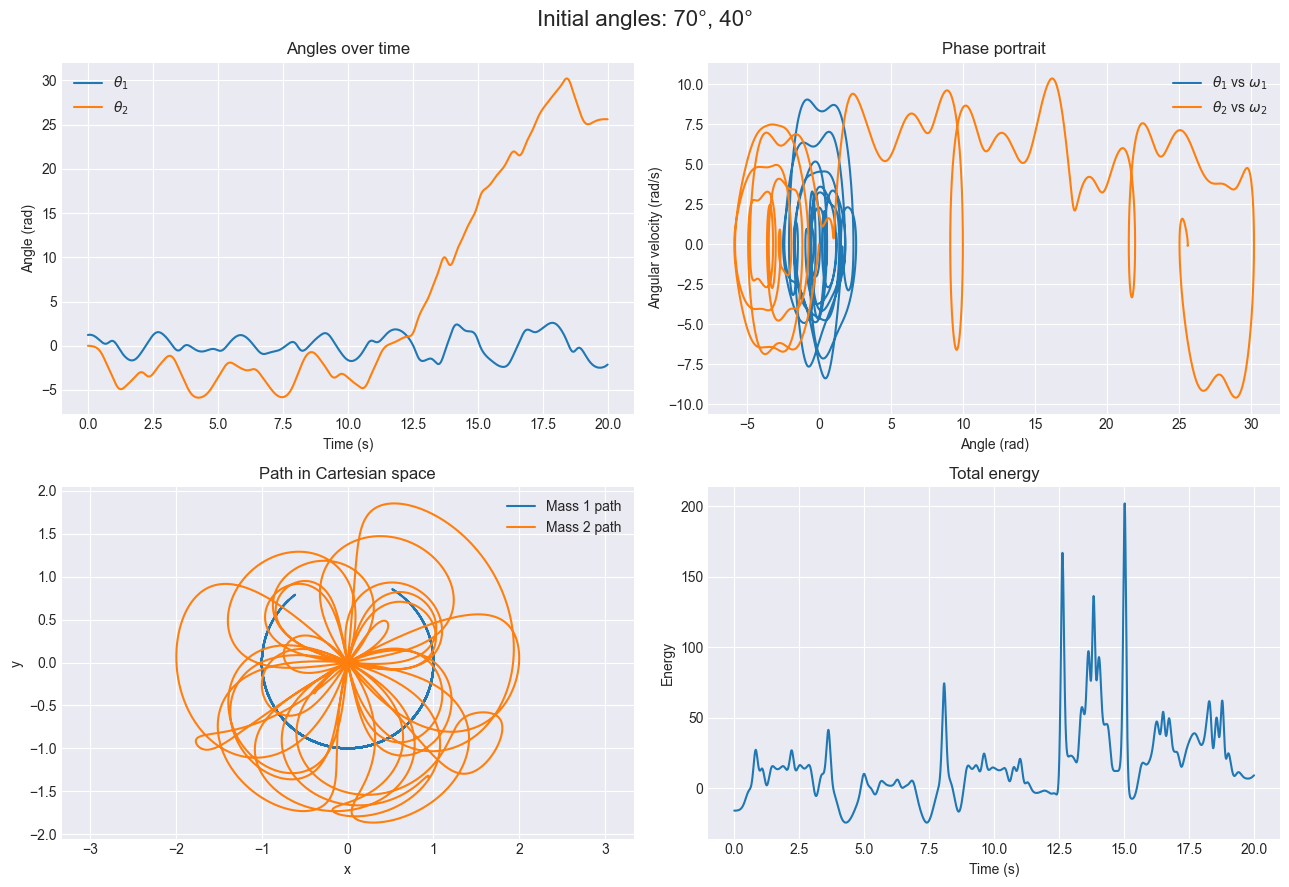

In [14]:
initial_conditions = [
    {'label': 'Initial angles: 20°, 10°', 'state': np.radians([20.0, 10.0, 0.0, 0.0])},
    {'label': 'Initial angles: 35°, 5°', 'state': np.radians([35.0, 5.0, 0.0, 0.0])},
    {'label': 'Initial angles: 50°, 25°', 'state': np.radians([50.0, 25.0, 0.0, 0.0])},
    {'label': 'Initial angles: 70°, 40°', 'state': np.radians([70.0, 40.0, 0.0, 0.0])},
]

results = []
for condition in initial_conditions:
    result = simulate_double_pendulum(condition['state'])
    results.append((condition['label'], result))
    plot_double_pendulum_summary(result, condition['label'])

The final cell gives a comparison plot for the bob-2 trajectory across all starting positions. This is a convenient place to swap in whatever graph family you want next.

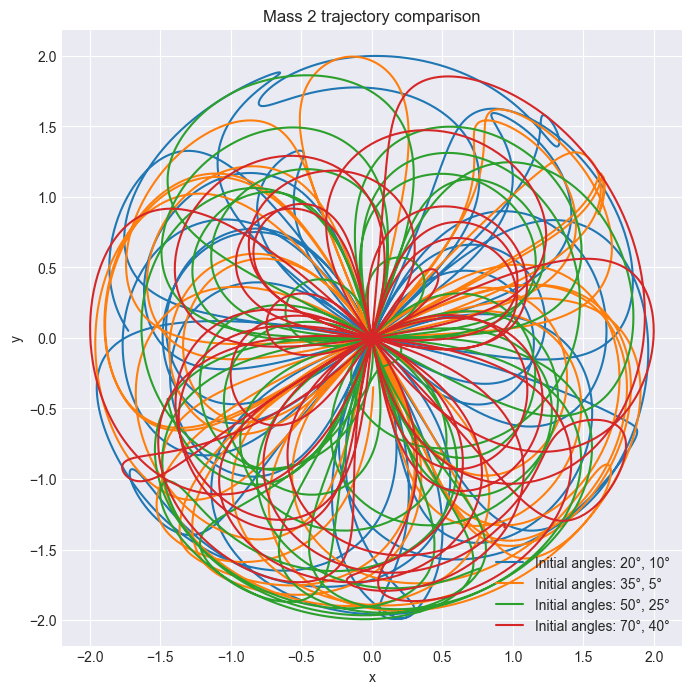

In [11]:
default_initial_conditions = [
    {'label': 'Initial angles: 20°, 10°', 'state': np.radians([20.0, 10.0, 0.0, 0.0])},
    {'label': 'Initial angles: 35°, 5°', 'state': np.radians([35.0, 5.0, 0.0, 0.0])},
    {'label': 'Initial angles: 50°, 25°', 'state': np.radians([50.0, 25.0, 0.0, 0.0])},
    {'label': 'Initial angles: 70°, 40°', 'state': np.radians([70.0, 40.0, 0.0, 0.0])},
]

conditions = globals().get('initial_conditions', default_initial_conditions)
results = globals().get('results')
if results is None or not results:
    results = []
    for condition in conditions:
        results.append((condition['label'], simulate_double_pendulum(condition['state'])))

fig, ax = plt.subplots(figsize=(8, 8))
for label, result in results:
    ax.plot(result['x2'], result['y2'], label=label)

ax.set_title('Mass 2 trajectory comparison')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.axis('equal')
ax.legend()
plt.show()